In [1]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from matplotlib.font_manager import FontProperties
font_path = "/mnt/nas2/home/genghaoyu/tools/fonts/Helvetica.ttc"  # 替换为Helvetica字体的路径
helvetica_bold = FontProperties(fname=font_path, weight='bold',size=20)

In [3]:
mse_dir = "/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/knapsack-gen-ood/mse/curve2-new-OOD-30-EERM-5-4.0-1e-2/"
# spo_dir = "/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/knapsack-gen-ood/spo/curve2-new-OOD-30-EERM-5-4.0-1e-2/"
spo_dir = "/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/knapsack-gen-ood/spo/curve2-new-OOD-30-EERM-1-1.0-5e-2/"

#new: 

In [4]:
mse_Loss = []
for iter_idx in range(1, 301):
    loss = torch.load(f"{mse_dir}/tensors/Loss-{iter_idx}.pt")
    mse_Loss.append(loss)
mse_Loss = torch.vstack(mse_Loss)

In [6]:
mse_Loss.shape

torch.Size([300, 6])

In [23]:
mse_Loss[-1]

tensor([3.0682e+10, 3.6635e+08, 1.1129e+09, 3.6494e+09, 9.1005e+09, 5.0578e+10])

In [5]:
end_epoch=100
df_mse = pd.DataFrame(
     {
    # 'train' : mse_Loss[:end_epoch,0] / 1e10 ,
    "env0" : mse_Loss[:end_epoch,1] / 1e10 ,
    "env1" : mse_Loss[:end_epoch,2] / 1e10 ,
    "env2" : mse_Loss[:end_epoch,3] / 1e10 ,
    "env3" : mse_Loss[:end_epoch,4] / 1e10 ,
    "env4" : mse_Loss[:end_epoch,5] / 1e13,
    "Epoch": np.arange(1,end_epoch+1),
    }
)
 
df_mse

,env0,env1,env2,env3,env4,Epoch
0,0.000010,0.000080,0.001955,0.127491,0.015765,1
1,0.000010,0.000079,0.001949,0.127411,0.015764,2
2,0.000010,0.000078,0.001944,0.127332,0.015762,3
3,0.000010,0.000078,0.001939,0.127252,0.015760,4
4,0.000009,0.000077,0.001933,0.127170,0.015759,5
...,...,...,...,...,...,...
95,0.001749,0.005122,0.014166,0.067666,0.013107,96
96,0.001835,0.005382,0.014951,0.068029,0.013048,97
97,0.001924,0.005649,0.015761,0.068462,0.012990,98
98,0.002015,0.005923,0.016595,0.068965,0.012931,99


/tmp/ipykernel_31517/1276589349.py:9: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(df_mse, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


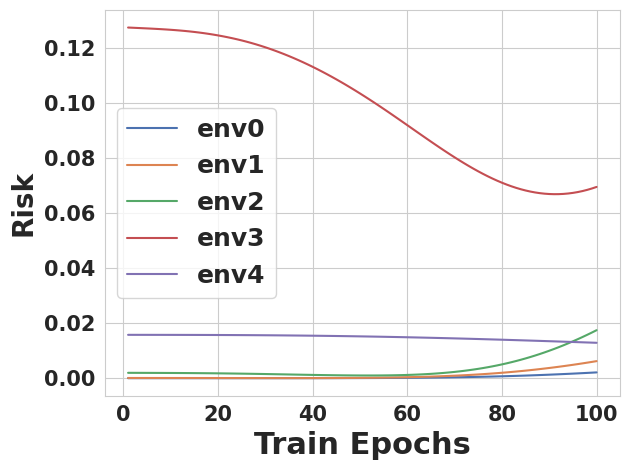

In [6]:
palette = sns.color_palette("deep")
sns.set_style("whitegrid")
# sns.set(font='Helvetica') # 替换'Helvetica'为你想要使用的字体
        # , rc={'axes.labelsize': 16, 'axes.titlesize': 18, 'font.size': 14, 'font.weight': 'bold'})

plt.figure()
metric_name="Risk"
# sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(df_pred_loss, ["Epoch"], value_name=metric_name, var_name='Method'))
sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(df_mse, ["Epoch"], value_name=metric_name, var_name='Method'))

plt.xlabel('Train Epochs',fontsize=22,fontweight='bold') 
plt.ylabel("Risk",fontsize=20,fontweight='bold') 
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
# plt.tick_params(labelsize=15)
legend_font = {
    # 'family': 'Arial',  # 字体
    'style': 'normal',
    'size': 18,  # 字号
    'weight': "bold",  # 是否加粗，不加粗
}
plt.legend(fontsize=18, prop=legend_font)
plt.tight_layout()
# plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/curve_pred.pdf',facecolor="w")

In [22]:
spo_Loss = []
for iter_idx in range(1, 301):
    loss = torch.load(f"{spo_dir}/tensors/Loss-{iter_idx}.pt")
    spo_Loss.append(loss)
spo_Loss = torch.vstack(spo_Loss)

### SPO train risk curve

In [23]:
df_spo = pd.DataFrame(
     {
    # 'train' : spo_Loss[:,0] / 1e10 /5,
    "env0" : spo_Loss[:,1] / 1e10 ,
    "env1" : spo_Loss[:,2] / 1e10 ,
    "env2" : spo_Loss[:,3] / 1e10 ,
    "env3" : spo_Loss[:,4] / 1e10 ,
    "env4" : spo_Loss[:,5] / 1e10,
    "Epoch": np.arange(1,301),
    }
)
 
df_mse

IndexError: index 2 is out of bounds for dimension 1 with size 2

/tmp/ipykernel_17784/2616367433.py:9: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(df_spo, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


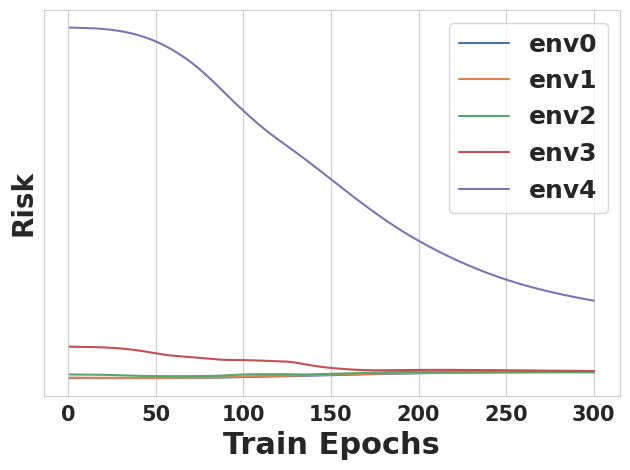

In [ ]:
palette = sns.color_palette("deep")
sns.set_style("whitegrid")
# sns.set(font='Helvetica') # 替换'Helvetica'为你想要使用的字体
        # , rc={'axes.labelsize': 16, 'axes.titlesize': 18, 'font.size': 14, 'font.weight': 'bold'})

plt.figure()
metric_name="Risk"
# sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(df_pred_loss, ["Epoch"], value_name=metric_name, var_name='Method'))
sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(df_spo, ["Epoch"], value_name=metric_name, var_name='Method'))

plt.xlabel('Train Epochs',fontsize=22,fontweight='bold') 
plt.ylabel("Risk",fontsize=20,fontweight='bold') 
plt.xticks(fontsize=15,fontweight='bold')
# plt.yticks(fontsize=15,fontweight='bold')
plt.yticks([])

# plt.tick_params(labelsize=15)
legend_font = {
    # 'family': 'Arial',  # 字体
    'style': 'normal',
    'size': 18,  # 字号
    'weight': "bold",  # 是否加粗，不加粗
}
plt.legend(fontsize=20, prop=legend_font)
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/ood_curve/spo_curve_train.pdf',facecolor="w")

### see color

In [36]:
palette = sns.color_palette("deep")
for i, color in enumerate(palette):
    print(f"Color {i+1}: {color}")

Color 1: (0.2980392156862745, 0.4470588235294118, 0.6901960784313725)
Color 2: (0.8666666666666667, 0.5176470588235295, 0.3215686274509804)
Color 3: (0.3333333333333333, 0.6588235294117647, 0.40784313725490196)
Color 4: (0.7686274509803922, 0.3058823529411765, 0.3215686274509804)
Color 5: (0.5058823529411764, 0.4470588235294118, 0.7019607843137254)
Color 6: (0.5764705882352941, 0.47058823529411764, 0.3764705882352941)
Color 7: (0.8549019607843137, 0.5450980392156862, 0.7647058823529411)
Color 8: (0.5490196078431373, 0.5490196078431373, 0.5490196078431373)
Color 9: (0.8, 0.7254901960784313, 0.4549019607843137)
Color 10: (0.39215686274509803, 0.7098039215686275, 0.803921568627451)


### load curve

In [24]:
mse_train = pd.read_csv(f"{mse_dir}/train_logs.csv")
spo_train = pd.read_csv(f"{spo_dir}/train_logs.csv")
mse_val = pd.read_csv(f"{mse_dir}/val_logs.csv")
spo_val = pd.read_csv(f"{spo_dir}/val_logs.csv")
mse_test = pd.read_csv(f"{mse_dir}/test_logs.csv")
spo_test = pd.read_csv(f"{spo_dir}/test_logs.csv")


In [10]:
mse_train

,epoch,obj,loss,pred_loss,eval
0,Tr-1,21920.490234,172535488.0,193896192.0,54358.398438
1,Tr-2,24574.849609,172514528.0,193874368.0,51704.039062
2,Tr-3,25593.531250,172493344.0,193852288.0,50685.359375
3,Tr-4,26513.193359,172471552.0,193829552.0,49765.695312
4,Tr-5,27024.755859,172448864.0,193805888.0,49254.132812
...,...,...,...,...,...
295,Tr-296,63118.601562,83897408.0,96221624.0,13160.287109
296,Tr-297,63126.886719,83801688.0,96106576.0,13152.002930
297,Tr-298,63126.886719,83707016.0,95992688.0,13152.002930
298,Tr-299,63131.460938,83613376.0,95879944.0,13147.427734


In [11]:
spo_train

,epoch,obj,loss,pred_loss,eval
0,Tr-1,35372.300781,73242.500000,193829328.0,40906.589844
1,Tr-2,42942.964844,73167.093750,193720896.0,33335.925781
2,Tr-3,41435.578125,73064.421875,193567824.0,34843.312500
3,Tr-4,40736.753906,72924.093750,193352560.0,35542.136719
4,Tr-5,39932.476562,72740.929688,193061920.0,36346.414062
...,...,...,...,...,...
295,Tr-296,74720.703125,11271.625977,369842816.0,1558.184326
296,Tr-297,74720.703125,11255.018555,371514080.0,1558.184326
297,Tr-298,74729.890625,11238.044922,373187040.0,1549.000000
298,Tr-299,74729.890625,11220.913086,374865664.0,1549.000000


In [38]:
opt_val = 1

import numpy as np
epochs = np.arange(300)
df_pred_loss_train = pd.DataFrame({ 
                "Epoch":epochs,
                "Inv-PnCO:Two-Stage": mse_train["pred_loss"].values/1e8,
                "Inv-PnCO:SPO":spo_train["pred_loss"].values/1e8,
                })
df_regret_train = pd.DataFrame({ 
                "Epoch": epochs,
                "Inv-PnCO:Two-Stage": mse_train["eval"].values/opt_val,
                "Inv-PnCO:SPO":spo_train["eval"].values/opt_val,
                })

### val
df_pred_loss_val = pd.DataFrame({ 
                "Epoch":epochs,
                "Inv-PnCO:Two-Stage": mse_val["pred_loss"].values/1e8,
                "Inv-PnCO:SPO":spo_val["pred_loss"].values/1e8,
                })
df_regret_val = pd.DataFrame({ 
                "Epoch": epochs,
                "Inv-PnCO:Two-Stage": mse_val["eval"].values/opt_val,
                "Inv-PnCO:SPO":spo_val["eval"].values/opt_val,
                })

### test
df_pred_loss_test = pd.DataFrame({ 
                "Epoch":epochs,
                "Inv-PnCO:Two-Stage": mse_test["pred_loss"].values/1e8,
                "Inv-PnCO:SPO":spo_test["pred_loss"].values/1e8,
                })
df_regret_test = pd.DataFrame({ 
                "Epoch": epochs,
                "Inv-PnCO:Two-Stage": mse_test["eval"].values/opt_val,
                "Inv-PnCO:SPO":spo_test["eval"].values/opt_val,
                })

#### train pred loss

/tmp/ipykernel_31517/3878903621.py:8: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(df_pred_loss_train, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


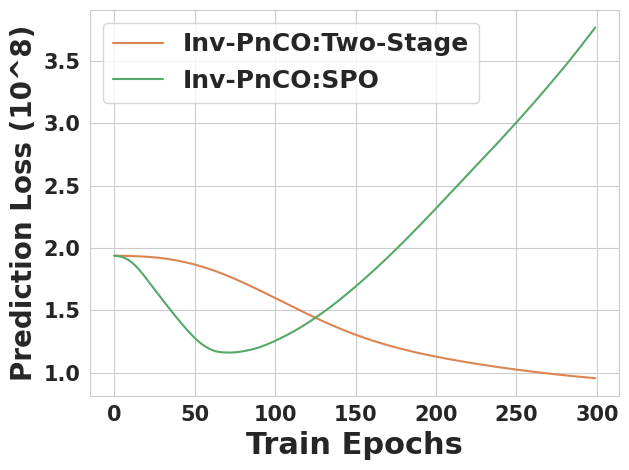

In [44]:
palette = sns.color_palette("deep")[1:]
sns.set_style("whitegrid")
# sns.set(font='Helvetica') # 替换'Helvetica'为你想要使用的字体
        # , rc={'axes.labelsize': 16, 'axes.titlesize': 18, 'font.size': 14, 'font.weight': 'bold'})

plt.figure()
metric_name="Pred Loss"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(df_pred_loss_train, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold') 
plt.ylabel("Prediction Loss (10^8)",fontsize=20,fontweight='bold') 
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
# plt.tick_params(labelsize=15)
legend_font = {
    # 'family': 'Arial',  # 字体
    'style': 'normal',
    'size': 18,  # 字号
    'weight': "bold",  # 是否加粗，不加粗
}
plt.legend(fontsize=18, prop=legend_font)
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/ood_curve/pred_loss_train.pdf',facecolor="w")

#### train regret

/tmp/ipykernel_31517/4023626191.py:6: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method",palette = palette, data=pd.melt(df_regret_train, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


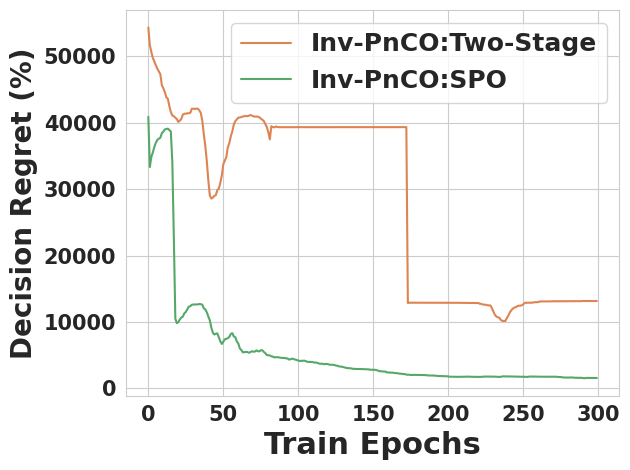

In [45]:
palette = sns.color_palette("deep")[1:]
sns.set_style("whitegrid")

plt.figure()
metric_name="Regret"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method",palette = palette, data=pd.melt(df_regret_train, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold')
plt.ylabel("Decision Regret (%)",fontsize=20,fontweight='bold')
# plt.tick_params(labelsize=15)
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
plt.legend(fontsize=20,prop=legend_font) 
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/ood_curve/regret_train.pdf', facecolor="w")

plt.show()

#### val pred loss

/tmp/ipykernel_31517/2051589543.py:8: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(df_pred_loss_val, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


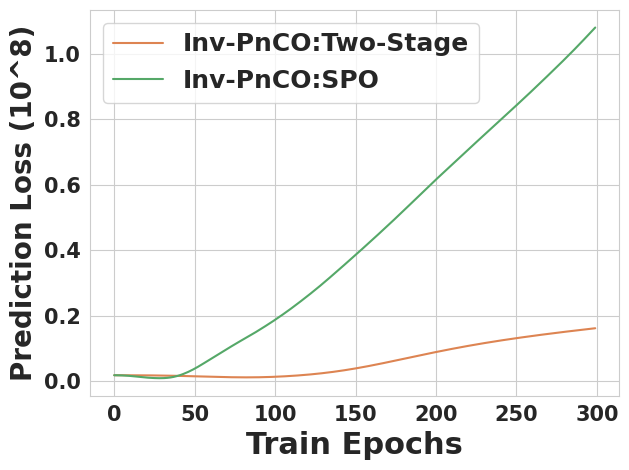

In [46]:
palette = sns.color_palette("deep")[1:]
sns.set_style("whitegrid")
# sns.set(font='Helvetica') # 替换'Helvetica'为你想要使用的字体
        # , rc={'axes.labelsize': 16, 'axes.titlesize': 18, 'font.size': 14, 'font.weight': 'bold'})

plt.figure()
metric_name="Pred Loss"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(df_pred_loss_val, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold') 
plt.ylabel("Prediction Loss (10^8)",fontsize=20,fontweight='bold') 
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
# plt.tick_params(labelsize=15)
legend_font = {
    # 'family': 'Arial',  # 字体
    'style': 'normal',
    'size': 18,  # 字号
    'weight': "bold",  # 是否加粗，不加粗
}
plt.legend(fontsize=18, prop=legend_font)
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/ood_curve/pred_loss_val.pdf',facecolor="w")

#### val regret

/tmp/ipykernel_31517/3764170164.py:6: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method",palette = palette, data=pd.melt(df_regret_val, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


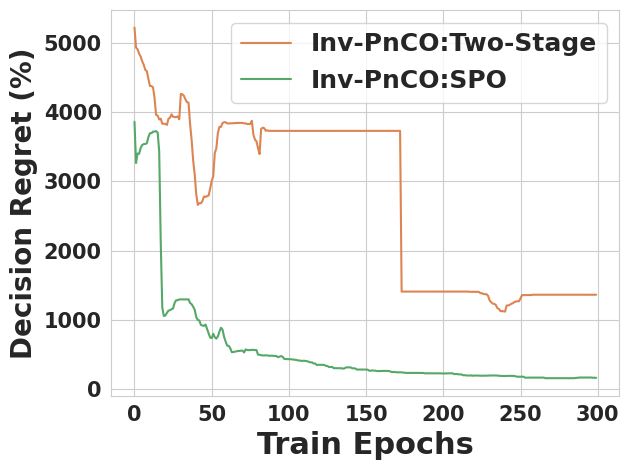

In [47]:
palette = sns.color_palette("deep")[1:]
sns.set_style("whitegrid")

plt.figure()
metric_name="Regret"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method",palette = palette, data=pd.melt(df_regret_val, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold')
plt.ylabel("Decision Regret (%)",fontsize=20,fontweight='bold')
# plt.tick_params(labelsize=15)
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
plt.legend(fontsize=20,prop=legend_font) 
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/ood_curve/regret_val.pdf', facecolor="w")

plt.show()

#### test pred loss

/tmp/ipykernel_31517/958602085.py:8: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(df_pred_loss_test, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


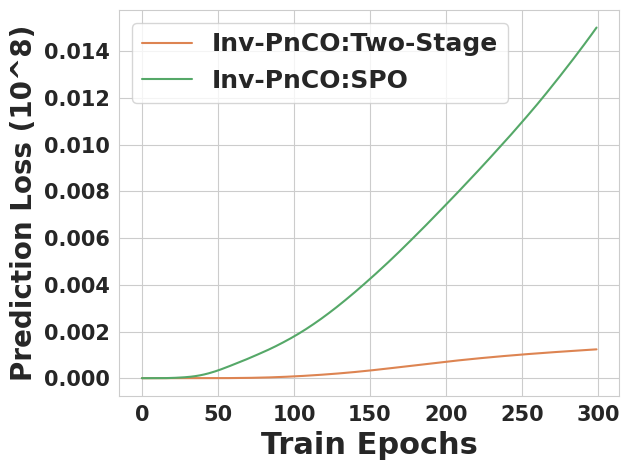

In [48]:
palette = sns.color_palette("deep")[1:]
sns.set_style("whitegrid")
# sns.set(font='Helvetica') # 替换'Helvetica'为你想要使用的字体
        # , rc={'axes.labelsize': 16, 'axes.titlesize': 18, 'font.size': 14, 'font.weight': 'bold'})

plt.figure()
metric_name="Pred Loss"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(df_pred_loss_test, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold') 
plt.ylabel("Prediction Loss (10^8)",fontsize=20,fontweight='bold') 
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
# plt.tick_params(labelsize=15)
legend_font = {
    # 'family': 'Arial',  # 字体
    'style': 'normal',
    'size': 18,  # 字号
    'weight': "bold",  # 是否加粗，不加粗
}
plt.legend(fontsize=18, prop=legend_font)
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/ood_curve/pred_loss_test.pdf',facecolor="w")

#### test regret

/tmp/ipykernel_31517/4102624649.py:6: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method",palette = palette, data=pd.melt(df_regret_test, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


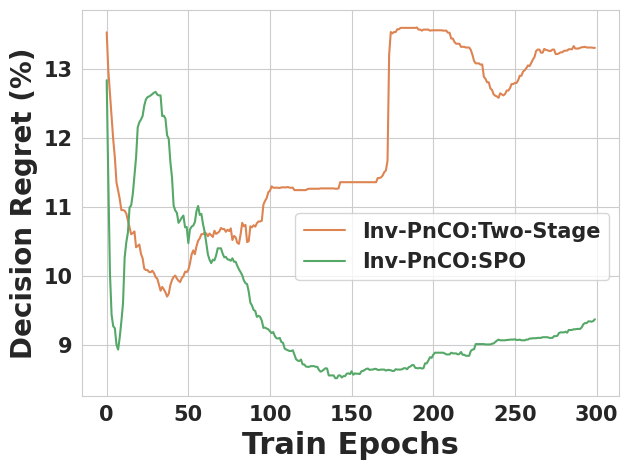

In [57]:
palette = sns.color_palette("deep")[1:]
sns.set_style("whitegrid")

plt.figure()
metric_name="Regret"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method",palette = palette, data=pd.melt(df_regret_test, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold')
plt.ylabel("Decision Regret (%)",fontsize=20,fontweight='bold')
# plt.tick_params(labelsize=15)
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
legend_font = {
    # 'family': 'Arial',  # 字体
    'style': 'normal',
    'size': 15,  # 字号
    'weight': "bold",  # 是否加粗，不加粗
}
plt.legend(prop=legend_font, bbox_to_anchor=(1,0.5)) 
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/ood_curve/regret_test.pdf', facecolor="w")

plt.show()

# IID curve

In [4]:
iid_mse_dir = "/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/knapsack-gen-ood/mse/curve2-new-IID-30/"
iid_spo_dir = "/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/knapsack-gen-ood/spo/curve2-new-IID-30/"

iid_mse_train = pd.read_csv(f"{iid_mse_dir}/train_logs.csv")
iid_spo_train = pd.read_csv(f"{iid_spo_dir}/train_logs.csv")
iid_mse_val = pd.read_csv(f"{iid_mse_dir}/val_logs.csv")
iid_spo_val = pd.read_csv(f"{iid_spo_dir}/val_logs.csv")
iid_mse_test = pd.read_csv(f"{iid_mse_dir}/test_logs.csv")
iid_spo_test = pd.read_csv(f"{iid_spo_dir}/test_logs.csv")


In [5]:
iid_mse_train

,epoch,obj,loss,pred_loss,eval
0,Tr-1,22.424999,26.044720,26.210070,13.856250
1,Tr-2,23.109375,25.292809,25.438782,13.171875
2,Tr-3,23.481251,24.537727,24.664135,12.800000
3,Tr-4,23.728125,23.771038,23.877331,12.553125
4,Tr-5,24.012501,22.985680,23.071171,12.268750
...,...,...,...,...,...
295,Tr-296,34.509377,2.019576,1.982954,1.771875
296,Tr-297,34.506248,2.018341,1.981736,1.775000
297,Tr-298,34.506248,2.017113,1.980521,1.775000
298,Tr-299,34.506248,2.015896,1.979313,1.775000


In [9]:

opt_val = 1

import numpy as np
epochs = np.arange(300)
iid_df_pred_loss_train = pd.DataFrame({ 
                "Epoch":epochs,
                "IID:Two-Stage": iid_mse_train["pred_loss"].values/1e8,
                "IID:SPO":iid_spo_train["pred_loss"].values/1e8,
                })
iid_df_regret_train = pd.DataFrame({ 
                "Epoch": epochs,
                "IID:Two-Stage": iid_mse_train["eval"].values/opt_val,
                "IID:SPO":iid_spo_train["eval"].values/opt_val,
                })

### val
iid_df_pred_loss_val = pd.DataFrame({ 
                "Epoch":epochs,
                "IID:Two-Stage": iid_mse_val["pred_loss"].values/1e8,
                "IID:SPO":iid_spo_val["pred_loss"].values/1e8,
                })
iid_df_regret_val = pd.DataFrame({ 
                "Epoch": epochs,
                "IID:Two-Stage": iid_mse_val["eval"].values/opt_val,
                "IID:SPO":iid_spo_val["eval"].values/opt_val,
                })

### test
iid_df_pred_loss_test = pd.DataFrame({ 
                "Epoch":epochs,
                "IID:Two-Stage": iid_mse_test["pred_loss"].values/1e8,
                "Inv-PnCO:SPO":iid_spo_test["pred_loss"].values/1e8,
                })
iid_df_regret_test = pd.DataFrame({ 
                "Epoch": epochs,
                "IID:Two-Stage": iid_mse_test["eval"].values/opt_val,
                "IID:SPO":iid_spo_test["eval"].values/opt_val,
                })

### IID train pred loss

/tmp/ipykernel_3130/2739827561.py:8: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(iid_df_pred_loss_train, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


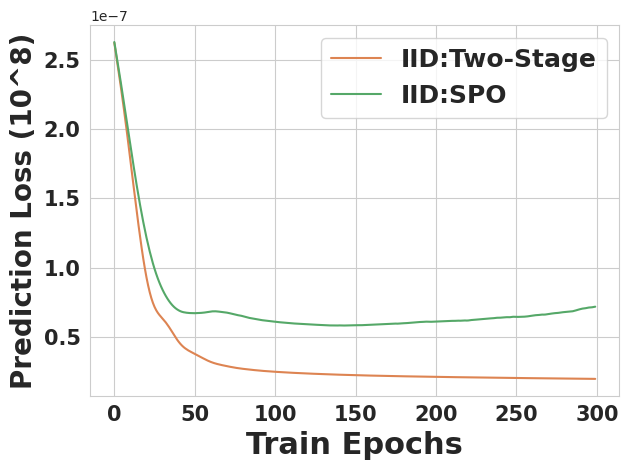

In [12]:
palette = sns.color_palette("deep")[1:]
sns.set_style("whitegrid")
# sns.set(font='Helvetica') # 替换'Helvetica'为你想要使用的字体
        # , rc={'axes.labelsize': 16, 'axes.titlesize': 18, 'font.size': 14, 'font.weight': 'bold'})

plt.figure()
metric_name="Pred Loss"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(iid_df_pred_loss_train, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold') 
plt.ylabel("Prediction Loss (10^8)",fontsize=20,fontweight='bold') 
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
# plt.tick_params(labelsize=15)
legend_font = {
    # 'family': 'Arial',  # 字体
    'style': 'normal',
    'size': 18,  # 字号
    'weight': "bold",  # 是否加粗，不加粗
}
plt.legend(fontsize=18, prop=legend_font)
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/iid_curve/pred_loss_train.pdf',facecolor="w")
plt.show()

### IID train regret

/tmp/ipykernel_3130/3215085392.py:6: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method",palette = palette, data=pd.melt(iid_df_regret_train, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


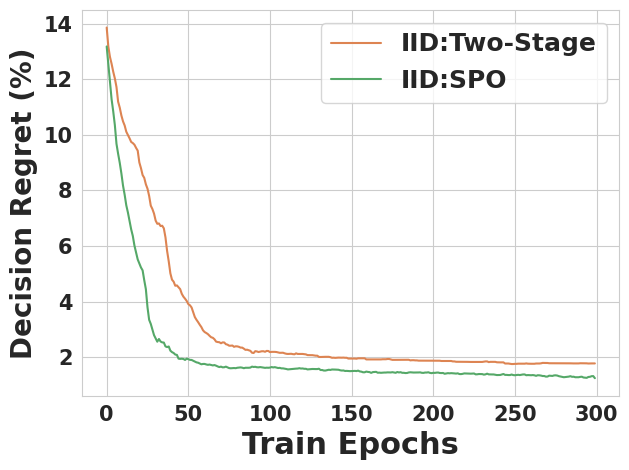

In [13]:
palette = sns.color_palette("deep")[1:]
sns.set_style("whitegrid")

plt.figure()
metric_name="Regret"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method",palette = palette, data=pd.melt(iid_df_regret_train, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold')
plt.ylabel("Decision Regret (%)",fontsize=20,fontweight='bold')
# plt.tick_params(labelsize=15)
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
plt.legend(fontsize=20,prop=legend_font) 
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/iid_curve/regret_train.pdf', facecolor="w")

plt.show()

### IID val pred loss

/tmp/ipykernel_3130/2204330936.py:8: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(iid_df_pred_loss_val, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


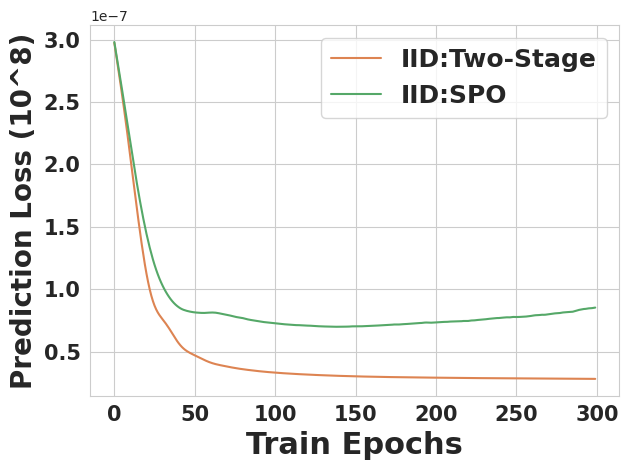

In [14]:
palette = sns.color_palette("deep")[1:]
sns.set_style("whitegrid")
# sns.set(font='Helvetica') # 替换'Helvetica'为你想要使用的字体
        # , rc={'axes.labelsize': 16, 'axes.titlesize': 18, 'font.size': 14, 'font.weight': 'bold'})

plt.figure()
metric_name="Pred Loss"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(iid_df_pred_loss_val, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold') 
plt.ylabel("Prediction Loss (10^8)",fontsize=20,fontweight='bold') 
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
# plt.tick_params(labelsize=15)
legend_font = {
    # 'family': 'Arial',  # 字体
    'style': 'normal',
    'size': 18,  # 字号
    'weight': "bold",  # 是否加粗，不加粗
}
plt.legend(fontsize=18, prop=legend_font)
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/iid_curve/pred_loss_val.pdf',facecolor="w")

### IID val regret

/tmp/ipykernel_3130/598932574.py:6: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method",palette = palette, data=pd.melt(iid_df_regret_val, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


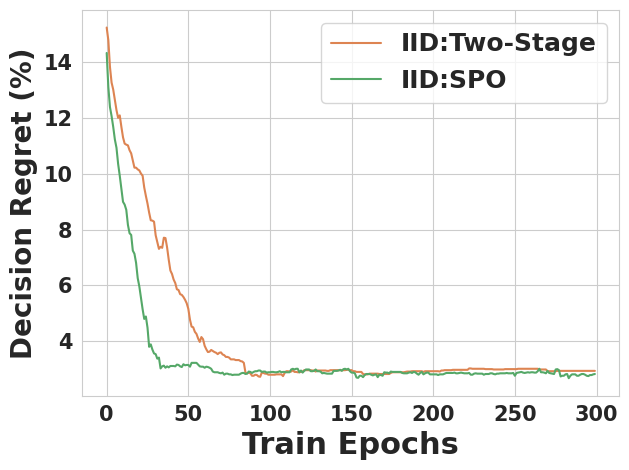

In [15]:
palette = sns.color_palette("deep")[1:]
sns.set_style("whitegrid")

plt.figure()
metric_name="Regret"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method",palette = palette, data=pd.melt(iid_df_regret_val, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold')
plt.ylabel("Decision Regret (%)",fontsize=20,fontweight='bold')
# plt.tick_params(labelsize=15)
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
plt.legend(fontsize=20,prop=legend_font) 
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/iid_curve/regret_val.pdf', facecolor="w")

plt.show()

### IID test pred loss

/tmp/ipykernel_3130/2333991281.py:8: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(iid_df_pred_loss_test, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


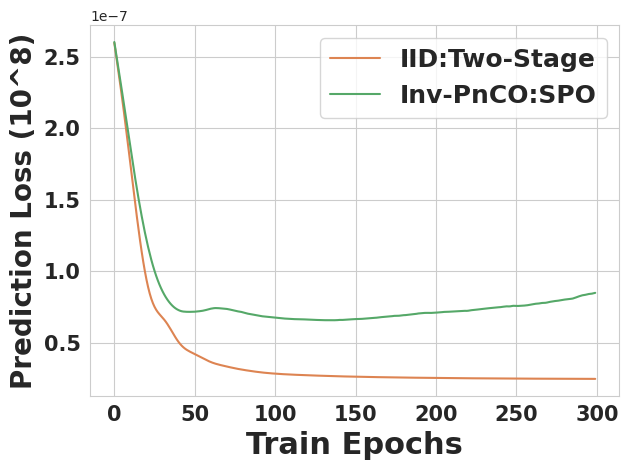

In [16]:
palette = sns.color_palette("deep")[1:]
sns.set_style("whitegrid")
# sns.set(font='Helvetica') # 替换'Helvetica'为你想要使用的字体
        # , rc={'axes.labelsize': 16, 'axes.titlesize': 18, 'font.size': 14, 'font.weight': 'bold'})

plt.figure()
metric_name="Pred Loss"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(iid_df_pred_loss_test, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold') 
plt.ylabel("Prediction Loss (10^8)",fontsize=20,fontweight='bold') 
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
# plt.tick_params(labelsize=15)
legend_font = {
    # 'family': 'Arial',  # 字体
    'style': 'normal',
    'size': 18,  # 字号
    'weight': "bold",  # 是否加粗，不加粗
}
plt.legend(fontsize=18, prop=legend_font)
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/iid_curve/pred_loss_test.pdf',facecolor="w")

### IID test regret

/tmp/ipykernel_3130/181150090.py:6: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method",palette = palette, data=pd.melt(iid_df_regret_test, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


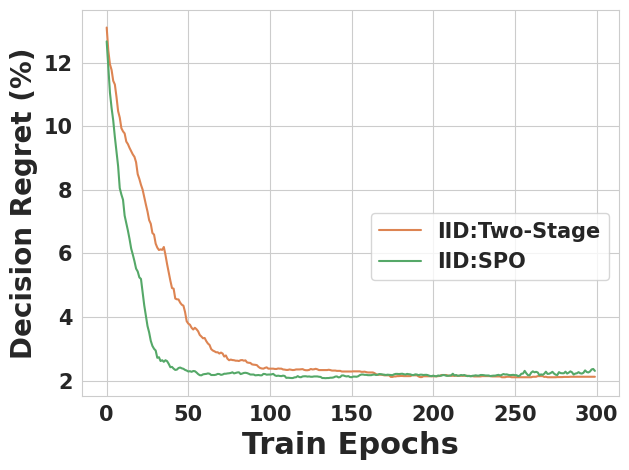

In [17]:
palette = sns.color_palette("deep")[1:]
sns.set_style("whitegrid")

plt.figure()
metric_name="Regret"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method",palette = palette, data=pd.melt(iid_df_regret_test, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold')
plt.ylabel("Decision Regret (%)",fontsize=20,fontweight='bold')
# plt.tick_params(labelsize=15)
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
legend_font = {
    # 'family': 'Arial',  # 字体
    'style': 'normal',
    'size': 15,  # 字号
    'weight': "bold",  # 是否加粗，不加粗
}
plt.legend(prop=legend_font, bbox_to_anchor=(1,0.5)) 
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/iid_curve/regret_test.pdf', facecolor="w")

plt.show()

# new curve with erm

In [3]:
erm_mse_dir = "/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/knapsack-gen-ood/mse/curve2-new-OOD-ERM-30"
erm_spo_dir = "/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/knapsack-gen-ood/spo/curve2-new-OOD-ERM-30"

erm_mse_train = pd.read_csv(f"{erm_mse_dir}/train_logs.csv")
erm_spo_train = pd.read_csv(f"{erm_spo_dir}/train_logs.csv")
erm_mse_val = pd.read_csv(f"{erm_mse_dir}/val_logs.csv")
erm_spo_val = pd.read_csv(f"{erm_spo_dir}/val_logs.csv")
erm_mse_test = pd.read_csv(f"{erm_mse_dir}/test_logs.csv")
erm_spo_test = pd.read_csv(f"{erm_spo_dir}/test_logs.csv")


In [4]:
opt_val = 1

import numpy as np
epochs = np.arange(300)
erm_df_pred_loss_train = pd.DataFrame({ 
                "Epoch":epochs,
                "ERM:Two-Stage": erm_mse_train["pred_loss"].values/1e8,
                "ERM:SPO":erm_spo_train["pred_loss"].values/1e8,
                # "Inv-PnCO:Two-Stage": mse_train["pred_loss"].values/1e8,
                # "Inv-PnCO:SPO":spo_train["pred_loss"].values/1e8,
                })
erm_df_regret_train = pd.DataFrame({ 
                "Epoch": epochs,
                "ERM:Two-Stage": erm_mse_train["eval"].values/opt_val,
                "ERM:SPO":erm_spo_train["eval"].values/opt_val,
                # "Inv-PnCO:Two-Stage": mse_train["eval"].values/opt_val,
                # "Inv-PnCO:SPO":spo_train["eval"].values/opt_val,
                })

### val
erm_df_pred_loss_val = pd.DataFrame({ 
                "Epoch":epochs,
                "ERM:Two-Stage": erm_mse_val["pred_loss"].values/1e8,
                "ERM:SPO": erm_spo_val["pred_loss"].values/1e8,
                # "Inv-PnCO:Two-Stage": mse_val["pred_loss"].values/1e8,
                # "Inv-PnCO:SPO":spo_val["pred_loss"].values/1e8,
                })
erm_df_regret_val = pd.DataFrame({ 
                "Epoch": epochs,
                "ERM:Two-Stage": erm_mse_val["eval"].values/opt_val,
                "ERM:SPO": erm_spo_val["eval"].values/opt_val,
                # "Inv-PnCO:Two-Stage": mse_val["eval"].values/opt_val,
                # "Inv-PnCO:SPO":spo_val["eval"].values/opt_val,
                })

### test
erm_df_pred_loss_test = pd.DataFrame({ 
                "Epoch":epochs,
                "ERM:Two-Stage": erm_mse_test["pred_loss"].values/1e8,
                "ERM:SPO":erm_spo_test["pred_loss"].values/1e8,
                # "Inv-PnCO:Two-Stage": mse_test["pred_loss"].values/1e8,
                # "Inv-PnCO:SPO":spo_test["pred_loss"].values/1e8,
                })
erm_df_regret_test = pd.DataFrame({ 
                "Epoch": epochs,
                "ERM:Two-Stage": erm_mse_test["eval"].values/opt_val,
                "ERM:SPO":erm_spo_test["eval"].values/opt_val,
                # "Inv-PnCO:Two-Stage": mse_test["eval"].values/opt_val,
                # "Inv-PnCO:SPO":spo_test["eval"].values/opt_val,
                })

### ERM train pred loss

/tmp/ipykernel_24571/2412061241.py:8: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(erm_df_pred_loss_train, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


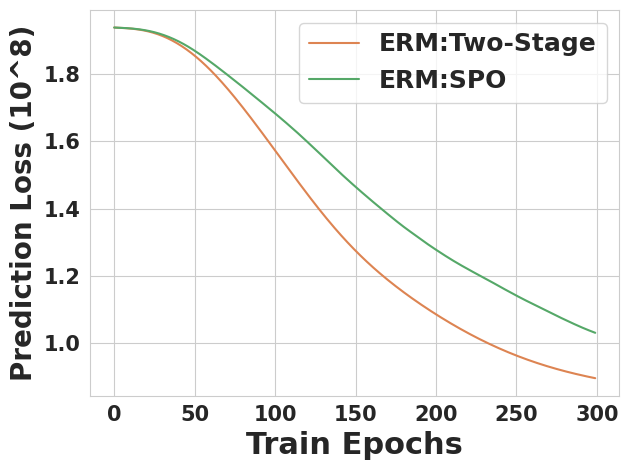

In [5]:
palette = sns.color_palette("deep")[1:]
sns.set_style("whitegrid")
# sns.set(font='Helvetica') # 替换'Helvetica'为你想要使用的字体
        # , rc={'axes.labelsize': 16, 'axes.titlesize': 18, 'font.size': 14, 'font.weight': 'bold'})

plt.figure()
metric_name="Pred Loss"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(erm_df_pred_loss_train, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold') 
plt.ylabel("Prediction Loss (10^8)",fontsize=20,fontweight='bold') 
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
# plt.tick_params(labelsize=15)
legend_font = {
    # 'family': 'Arial',  # 字体
    'style': 'normal',
    'size': 18,  # 字号
    'weight': "bold",  # 是否加粗，不加粗
}
plt.legend(fontsize=18, prop=legend_font)
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/erm_curve/pred_loss_train.pdf',facecolor="w")
plt.show()

### ERM train regret

/tmp/ipykernel_24571/1568108851.py:6: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method",palette = palette, data=pd.melt(erm_df_regret_train, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


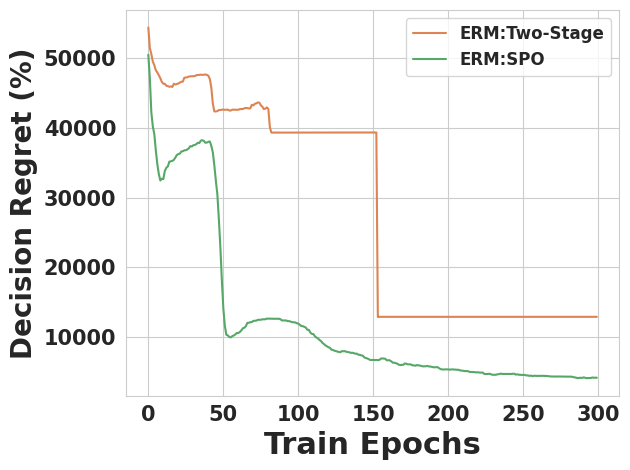

In [6]:
palette = sns.color_palette("deep")[1:]
sns.set_style("whitegrid")

plt.figure()
metric_name="Regret"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method",palette = palette, data=pd.melt(erm_df_regret_train, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold')
plt.ylabel("Decision Regret (%)",fontsize=20,fontweight='bold')
# plt.tick_params(labelsize=15)
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
legend_font = {
    # 'family': 'Arial',  # 字体
    'style': 'normal',
    'size': 12,  # 字号
    'weight': "bold",  # 是否加粗，不加粗
}
plt.legend(prop=legend_font) 
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/erm_curve/regret_train.pdf', facecolor="w")

plt.show()

### ERM valid pred loss

/tmp/ipykernel_24571/940229094.py:8: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(erm_df_pred_loss_val, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


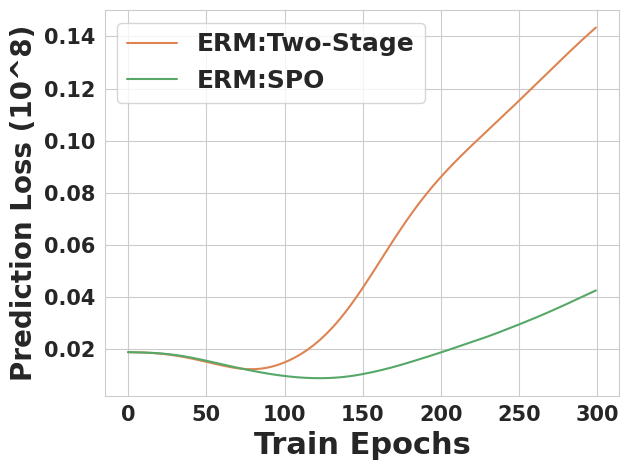

In [7]:
palette = sns.color_palette("deep")[1:]
sns.set_style("whitegrid")
# sns.set(font='Helvetica') # 替换'Helvetica'为你想要使用的字体
        # , rc={'axes.labelsize': 16, 'axes.titlesize': 18, 'font.size': 14, 'font.weight': 'bold'})

plt.figure()
metric_name="Pred Loss"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(erm_df_pred_loss_val, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold') 
plt.ylabel("Prediction Loss (10^8)",fontsize=20,fontweight='bold') 
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
# plt.tick_params(labelsize=15)
legend_font = {
    # 'family': 'Arial',  # 字体
    'style': 'normal',
    'size': 18,  # 字号
    'weight': "bold",  # 是否加粗，不加粗
}
plt.legend(fontsize=18, prop=legend_font)
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/erm_curve/pred_loss_val.pdf',facecolor="w")
plt.show()

### ERM valid regret

/tmp/ipykernel_24571/3066522114.py:6: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method",palette = palette, data=pd.melt(erm_df_regret_val, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


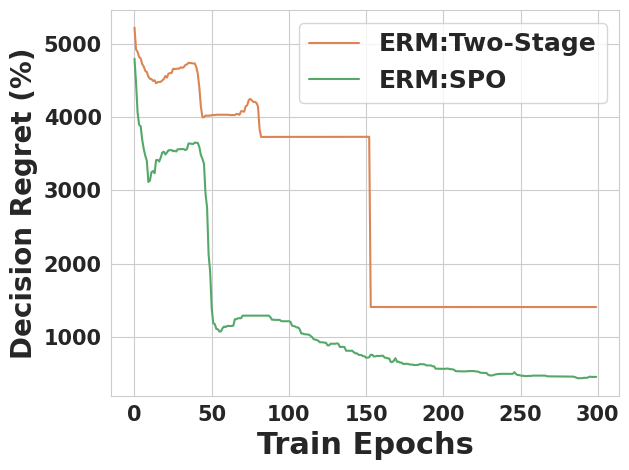

In [8]:
palette = sns.color_palette("deep")[1:]
sns.set_style("whitegrid")

plt.figure()
metric_name="Regret"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method",palette = palette, data=pd.melt(erm_df_regret_val, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold')
plt.ylabel("Decision Regret (%)",fontsize=20,fontweight='bold')
# plt.tick_params(labelsize=15)
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
plt.legend(fontsize=20,prop=legend_font) 
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/erm_curve/regret_val.pdf', facecolor="w")

plt.show()

### ERM test pred loss

/tmp/ipykernel_24571/1825876250.py:8: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(erm_df_pred_loss_test, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


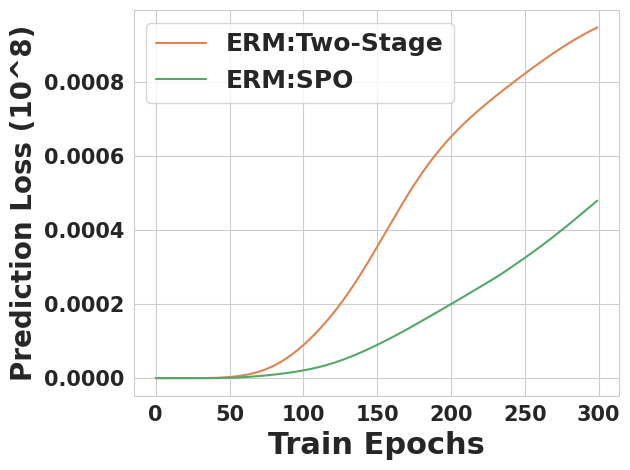

In [9]:
palette = sns.color_palette("deep")[1:]
sns.set_style("whitegrid")
# sns.set(font='Helvetica') # 替换'Helvetica'为你想要使用的字体
        # , rc={'axes.labelsize': 16, 'axes.titlesize': 18, 'font.size': 14, 'font.weight': 'bold'})

plt.figure()
metric_name="Pred Loss"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(erm_df_pred_loss_test, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold') 
plt.ylabel("Prediction Loss (10^8)",fontsize=20,fontweight='bold') 
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
# plt.tick_params(labelsize=15)
legend_font = {
    # 'family': 'Arial',  # 字体
    'style': 'normal',
    'size': 18,  # 字号
    'weight': "bold",  # 是否加粗，不加粗
}
plt.legend(fontsize=18, prop=legend_font)
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/erm_curve/pred_loss_test.pdf',facecolor="w")
plt.show()

### ERM test regret

In [28]:
df_regret_test

,Epoch,ERM:Two-Stage,ERM:SPO,Inv-PnCO:Two-Stage,Inv-PnCO:SPO
0,0,13.525,14.005,13.535,12.840
1,1,12.950,13.985,12.980,11.380
2,2,12.545,13.955,12.650,10.040
3,3,12.280,13.955,12.315,9.435
4,4,11.910,13.955,11.980,9.270
...,...,...,...,...,...
295,295,12.965,13.240,13.315,9.340
296,296,12.965,13.240,13.315,9.340
297,297,12.965,13.200,13.315,9.335
298,298,12.965,13.200,13.310,9.345


/tmp/ipykernel_24571/643587986.py:6: UserWarning: The palette list has more values (9) than needed (2), which may not be intended.
  sns.lineplot(x = "Epoch", y =metric_name , hue="Method",palette = palette, data=pd.melt(erm_df_regret_test, ["Epoch"], value_name=metric_name, var_name='Method'))
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/genghaoyu/anaconda3/envs/py39_cu102/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


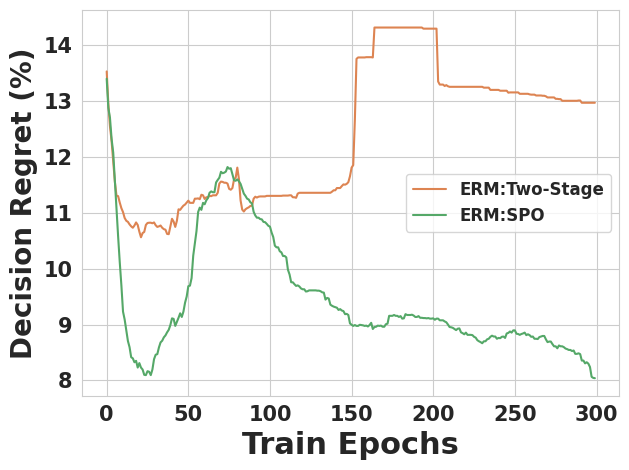

In [10]:
palette = sns.color_palette("deep")[1:]
sns.set_style("whitegrid")

plt.figure()
metric_name="Regret"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method",palette = palette, data=pd.melt(erm_df_regret_test, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold')
plt.ylabel("Decision Regret (%)",fontsize=20,fontweight='bold')
# plt.tick_params(labelsize=15)
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
legend_font = {
    # 'family': 'Arial',  # 字体
    'style': 'normal',
    'size': 12,  # 字号
    'weight': "bold",  # 是否加粗，不加粗
}
plt.legend(prop=legend_font) 
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/erm_curve/regret_test.pdf', facecolor="w")

plt.show()